## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Henry Fong]

**Date:** [10-01-2026]

1. What is the difference between regression and classification? **The difference between regression and classification is that regression is used for numeric target while classification is used for categorical target**
2. What is a confusion table? What does it help us understand about a model's performance? **A confusion table counts predictions by actual class and predicted class. It tells us the accuracy of a model's performance**
3. What does the SSE quantify about a particular model? **SSE quantify the misses that a particular model made with large misses having more impact than small misses**
4. What are overfitting and underfitting? **underfitting is when a model features cannot represent structure that is really in the outcome, while overfitting is when a flexible specification captures peculiarities of the training data that will not appear again.**
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance? **It allow us to fit a model based on the training set but also having a testing sets allow us to check how well the model predicts new observation. Allowing us to improve the model performance**
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach. **When we use a class label as a prediction we are able to predict each class as its own data point allowing us to see each individual class however it suffers from lack of accuracy requiring accuracy testing and confusion matrices. While using it as a probability we see a probabilty scale that tells us the chances that value is a specific class however it is prone to under or overfitting.**

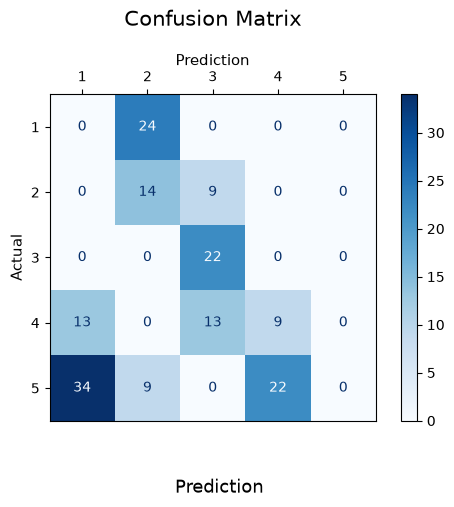

In [ ]:
import pandas as pd 
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('data/land_mines.csv')

"""
Q1:
There is 4 labels in this data set: voltage, height, soil, and mine_type.
Voltage is a float with a range between 0.0 and 1.0 
Height is a float with a range between 0.0 and 1.0
Soil is a float with a range between 0.0 and 1.0
Mine_type is a int with a range between 1 and 5
"""

# Q2
training_set = df[0:169]
testing_set = df[169:]

# Q3
# I selected k as 20 as if I had selected a small number like 3 or a large number like 50 I could have under or over fitted my data. so by picking 20 I stick to a middle ground where it was not too small nor was it too big
classification_X_raw = training_set[["voltage", "height"]]
classification_y = training_set["mine_type"]
classification_scaler = MinMaxScaler()
classification_X_scaled = pd.DataFrame(
    classification_scaler.fit_transform(classification_X_raw),
    columns=classification_X_raw.columns,
    index=classification_X_raw.index,
)
classification_model = KNeighborsClassifier(n_neighbors=20).fit(
    classification_X_scaled, classification_y
)

# Q4
"""
I would say this model is not really accurate as it was only accurate for 3 and slightly accurate for both 2 and 4 however for 5 and 1 it was entirely inaccurate. So as the model gets further out from the center its accuracy severely degrades
"""
# Sources used: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/
actual = testing_set["mine_type"].to_numpy()
predicted = classification_y.to_numpy()
classes = [1, 2, 3, 4, 5]
cm = confusion_matrix(actual, predicted, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

plt.show()

# Q5 
# The advice I would give to someone on this model is if the data is in the middle of the list such as if we have a class of [1,2,3,4,5] the middle part 3 is extremely accurate 
# while as you get further out of the center such as 2 and 4 it is slightly accurate such that it may give incorrect data but there is a possibility that it can still be accurate
# while the outliers such as 1 and 5 should not be trusted at all as not a single data point that was predicted that was correct.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [7c43034]
- **AI tool and model used:** [Google Gemini 3.8 Flash]

### *Prompts used

1. [Is this correct? 
1. What is the difference between regression and classification? **The difference between regression and classification is that regression is used for numeric target while classification is used for categorical target**
2. What is a confusion table? What does it help us understand about a model's performance? **A confusion table counts predictions by actual class and predicted class. It tells us the accuracy of a model's performance**
3. What does the SSE quantify about a particular model? **SSE quantify the misses that a particular model made with large misses having more impact than small misses**
4. What are overfitting and underfitting? **underfitting is when a model features cannot represent structure that is really in the outcome, while overfitting is when a flexible specification captures peculiarities of the training data that will not appear again.**
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance? **It allow us to fit a model based on the training set but also having a testing sets allow us to check how well the model predicts new observation. Allowing us to improve the model performance**
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach. **When we use a class label as a prediction we are able to predict each class as its own data point allowing us to see each individual class however it suffers from lack of accuracy requiring accuracy testing and confusion matrices. While using it as a probability we see a probabilty scale that tells us the chances that value is a specific class however it is prone to under or overfitting.**]
2. [Did I do these correctly? import pandas as pd 
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('data/land_mines.csv')

"""
Q1:
There is 4 labels in this data set: voltage, height, soil, and mine_type.
Voltage is a float with a range between 0.0 and 1.0 
Height is a float with a range between 0.0 and 1.0
Soil is a float with a range between 0.0 and 1.0
Mine_type is a int with a range between 1 and 5
"""

# Q2
training_set = df[0:169]
testing_set = df[169:]

# Q3
# I selected k as 20 as if I had selected a small number like 3 or a large number like 50 I could have under or over fitted my data. so by picking 20 I stick to a middle ground where it was not too small nor was it too big
classification_X_raw = training_set[["voltage", "height"]]
classification_y = training_set["mine_type"]
classification_scaler = MinMaxScaler()
classification_X_scaled = pd.DataFrame(
    classification_scaler.fit_transform(classification_X_raw),
    columns=classification_X_raw.columns,
    index=classification_X_raw.index,
)
classification_model = KNeighborsClassifier(n_neighbors=20).fit(
    classification_X_scaled, classification_y
)

# Q4
"""
I would say this model is not really accurate as it was only accurate for 3 and slightly accurate for both 2 and 4 however for 5 and 1 it was entirely inaccurate. So as the model gets further out from the center its accuracy severely degrades
"""
actual = testing_set["mine_type"].to_numpy()
predicted = classification_y.to_numpy()
classes = [1, 2, 3, 4, 5]
cm = confusion_matrix(actual, predicted, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

plt.show()

# Q5 
# The advice I would give to someone on this model is if the data is in the middle of the list such as if we have a class of [1,2,3,4,5] the middle part 3 is extremely accurate 
# while as you get further out of the center such as 2 and 4 it is slightly accurate such that it may give incorrect data but there is a possibility that it can still be accurate
# while the outliers such as 1 and 5 should not be trusted at all as not a single data point that was predicted that was correct.
]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Here is an evaluation of each answer, detailing where each is accurate and where key technical nuances should be corrected:

---

### Question 1: Regression vs. Classification

> **Your Answer:** "The difference between regression and classification is that regression is used for numeric target while classification is used for categorical target"

* **Evaluation:** **Accurate.**
* **Refinement:** Specifically, regression predicts a **continuous numerical value** (e.g., house price, temperature), whereas classification predicts a **discrete categorical label** (e.g., spam vs. not spam, image classes).

---

### Question 2: Confusion Table

> **Your Answer:** "A confusion table counts predictions by actual class and predicted class. It tells us the accuracy of a model's performance"

* **Evaluation:** **Partially correct, but incomplete on the second part.**
* **Correction:**
* The definition is correct: it tabulates actual vs. predicted classes.
* However, stating it just tells us "the accuracy" misses its primary purpose. Overall accuracy can be calculated without a full matrix, and accuracy is misleading on imbalanced datasets.
* **What it actually helps us understand:** It breaks down the **types of errors** the model makes by exposing **False Positives (Type I errors)** and **False Negatives (Type II errors)** alongside True Positives and True Negatives. This allows the calculation of class-specific metrics like **precision, recall (sensitivity), and specificity**.



---

### Question 3: Sum of Squared Errors (SSE)

> **Your Answer:** "SSE quantify the misses that a particular model made with large misses having more impact than small misses"

* **Evaluation:** **Accurate.**
* **Refinement:** The core intuition is spot-on. To formalize it:

$$\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$



It quantifies the total discrepancy (residual error) between observed values ($y_i$) and fitted values ($\hat{y}_i$). Squaring the residuals ensures positive and negative errors don't cancel out and disproportionately penalizes large outliers.

---

### Question 4: Underfitting vs. Overfitting

> **Your Answer:** "underfitting is when a model features cannot represent structure that is really in the outcome, while overfitting is when a flexible specification captures peculiarities of the training data that will not appear again."

* **Evaluation:** **Accurate.**
* **Refinement:** Well stated. In standard machine learning terminology:
* **Underfitting (High Bias):** The model is too simple to capture the underlying data trend, performing poorly on both training and unseen data.
* **Overfitting (High Variance):** The model is excessively complex, fitting noise and sample-specific artifacts in the training data, leading to strong training performance but poor generalization to test data.



---

### Question 5: Train/Test Split and Tuning $k$

> **Your Answer:** "It allow us to fit a model based on the training set but also having a testing sets allow us to check how well the model predicts new observation. Allowing us to improve the model performance"

* **Evaluation:** **Conceptually on track, but contains a methodological flaw (Data Leakage).**
* **Correction:**
* Evaluating on held-out data simulates performance on unseen observations, which is correct.
* **Crucial distinction:** In standard methodology, you do **not** select hyperparameters (like $k$ in $k$-NN) directly on the **test set**. If you tune $k$ using test-set performance, the test set influences model selection, leading to optimistic bias (data leakage).
* **Best practice:** You tune $k$ on a **validation set** (or via cross-validation on the training set). Once the best $k$ is selected, the **test set** is used strictly once for the final unbiased evaluation of generalization error.



---

### Question 6: Class Labels vs. Probability Distributions

> **Your Answer:** "When we use a class label as a prediction we are able to predict each class as its own data point allowing us to see each individual class however it suffers from lack of accuracy requiring accuracy testing and confusion matrices. While using it as a probability we see a probabilty scale that tells us the chances that value is a specific class however it is prone to under or overfitting."

* **Evaluation:** **Incorrect / Needs Restructuring.**
* **Correction:** Both approaches come from the same underlying model; probabilities are not inherently more prone to overfitting than discrete labels, nor does predicting labels cause a "lack of accuracy."

Here is the standard comparison of strengths and weaknesses:

* **Discrete Class Labels (e.g., "Class A" vs. "Class B"):**
* **Strengths:** Actionable and simple. Directly answers decision-making tasks where an immediate binary or categorical choice is required (e.g., route to spam folder or inbox).
* **Weaknesses:** Discards **confidence/uncertainty**. A prediction with 51% certainty looks identical to one with 99% certainty. It also hardcodes a decision boundary (typically 0.5 threshold), removing flexibility.


* **Probability Distributions (e.g., $P(\text{Class A}) = 0.85$, $P(\text{Class B}) = 0.15$):**
* **Strengths:** Quantifies **uncertainty** and model confidence. Enables post-hoc threshold tuning (e.g., lowering the threshold in medical diagnosis or fraud detection where false negatives are costly). Enables proper scoring rules (e.g., log-loss / cross-entropy, Brier score, ROC-AUC).
* **Weaknesses:** Requires choosing a decision threshold if a discrete action is ultimately required. Probabilities may also be uncalibrated (the model might output 0.90 confidence when true empirical accuracy is only 70%).



---

**Verdict:** Questions **1, 3, and 4** are correct. Question **2** needs the distinction regarding specific error types (False Positives/Negatives). Question **5** should mention validation sets rather than tuning on the test set. Question **6** needs to be revised to focus on uncertainty quantification versus decision simplicity.
2. Here is a section-by-section audit of your code and interpretations, highlighting a **critical bug in Q4** that invalidates your confusion matrix and your conclusions in Q5.

---

### Q1: Variable Descriptions

* **Terminology note:** In machine learning, call `voltage`, `height`, and `soil` **features** (or predictors/covariates), and `mine_type` the **target** (or label/response). Calling all four "labels" is technically inaccurate.
* Data types and ranges are clearly identified.

---

### Q2: Train/Test Split

* **Code:** `df[0:169]` and `df[169:]`
* **Risk (Sequential vs. Shuffled):** Slicing directly by row indices without shuffling assumes the dataset is already randomized. In datasets like `land_mines.csv`, observations are frequently sorted or grouped by `mine_type`. If row 0–168 contains mostly classes 1–3 and rows 169+ contain classes 4–5, your train and test splits will have severe class distribution shifts.
* **Safer alternative:**
```python
from sklearn.model_selection import train_test_split

# Using train_test_split preserves random distribution (and supports stratification)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["mine_type"])

```


*(If your lab explicitly instructed you to use index 169, keeping `df[0:169]` is fine—just ensure the dataset was already randomized).*

---

### Q3: Feature Scaling and Model Fitting

* **Code Logic:** The pipeline scaling `voltage` and `height` using `MinMaxScaler` and fitting `KNeighborsClassifier(n_neighbors=20)` is syntactically sound.
* **Conceptual Justification for $k=20$:** You wrote: *"if I had selected a small number like 3 or a large number like 50 I could have under or over fitted my data."* Be careful to match the correct direction:
* **Small $k$ (e.g., $k=1$ or $3$):** Captures noise, high variance $\rightarrow$ **Overfitting**.
* **Large $k$ (e.g., $k=50$):** Oversmoothes boundaries, high bias $\rightarrow$ **Underfitting**.
* Picking an arbitrary number like 20 by intuition is an educated guess, but formally $k$ should be selected by comparing performance across a range of $k$ values (e.g., testing $k \in [1, 35]$ on validation data).



---

### Q4: The Confusion Matrix Evaluation (Critical Bug)

Look at these two lines in your code:

```python
actual = testing_set["mine_type"].to_numpy()
predicted = classification_y.to_numpy() # <-- CRITICAL BUG

```

1. **What happened:**
* `classification_y` is `training_set["mine_type"]`.
* You did **not** call `classification_model.predict()` on the test features!
* You passed the **actual training labels** as your predictions against the **actual test labels**.
* If `len(training_set)` happened to equal `len(testing_set)` (or sliced to match), you were just comparing the ground truth of two arbitrary chunks of data against each other, not evaluating the model at all. If the lengths differed, it would throw a `ValueError: Found input variables with inconsistent numbers of samples`.


2. **How to fix it:**
You must transform the **test features** using the scaler fitted on the training data, then call `.predict()`:
```python
# 1. Scale testing features using the ALREADY FITTED scaler
test_X_raw = testing_set[["voltage", "height"]]
test_X_scaled = classification_scaler.transform(test_X_raw)

# 2. Generate actual predictions from the trained model
predicted = classification_model.predict(test_X_scaled)
actual = testing_set["mine_type"].to_numpy()

# 3. Build confusion matrix
classes = [1, 2, 3, 4, 5]
cm = confusion_matrix(actual, predicted, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.show()

```



---

### Q5: Analysis / Advice

* Because `predicted = classification_y.to_numpy()` caused the bug in Q4, your entire analysis about classes 1 and 5 having zero accuracy and class 3 being central was based on invalid data.
* **Why did classes 1 and 5 appear to have zero accuracy in your run?** Because the first 169 rows and the remaining rows held completely different slices of the target values, so you were aligning mismatched class rows.
* Once you fix Q4 and predict on `test_X_scaled`, re-run the matrix. Your advice should be updated based on the **real** precision, recall, and false-positive/false-negative patterns shown in the corrected plot.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | **Accept** / modify / reject | There were some questions that I felt that I did not fully understand correctly such as part 6 and AI explanation helped to give a more accurate and precise answer |
| 2 | **Accept** / modify / reject | There was some incorrect part of my code which ai told me about and gave me suggestions on how to fix the code |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

1. What is the difference between regression and classification? **The difference between regression and classification is that regression is used for numeric target while classification is used for categorical target**
2. What is a confusion table? What does it help us understand about a model's performance? **A confusion table counts predictions by actual class and predicted class. It tells us the accuracy of a model's performance by breaking down the types of errors the model makes such as Type I errors or Type II errors**
3. What does the SSE quantify about a particular model? **SSE quantify the misses that a particular model made with large misses having more impact than small misses**
4. What are overfitting and underfitting? **underfitting is when a model features cannot represent structure that is really in the outcome, while overfitting is when a flexible specification captures peculiarities of the training data that will not appear again.**
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance? **It allow us to fit a model based on the training set but also having a testing sets allow us to check how well the model predicts new observation by tuning K value it allow us to improve the model performance**
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach. **When we use a class label as a prediction its strength are it is actionable and simple while its weaknesses are that it discard confidence/uncertainity. While when we use probability distributions its strengths are it quantifies uncertainty and model confidence while its weaknesses are it requires choosing a decision threshold if a discrete action is ultimately required**

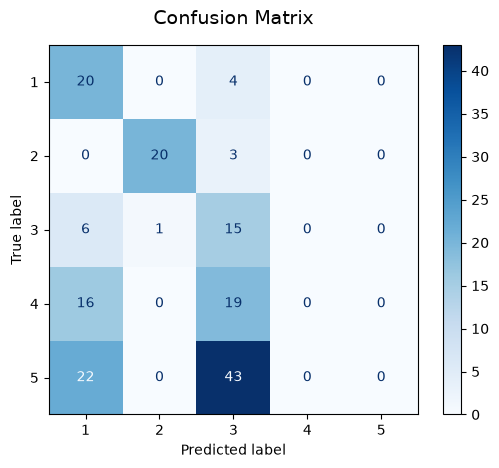

In [3]:
import pandas as pd 
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('data/land_mines.csv')

# Q2: Train / Test Split
training_set = df.iloc[0:169]
testing_set = df.iloc[169:]

# Q3: Fit Scaler and Model on Training Data
classification_X_raw = training_set[["voltage", "height"]]
classification_y = training_set["mine_type"]

classification_scaler = MinMaxScaler()
classification_X_scaled = classification_scaler.fit_transform(classification_X_raw)

classification_model = KNeighborsClassifier(n_neighbors=20)
classification_model.fit(classification_X_scaled, classification_y)

# Q4: Transform Test Data and Predict
test_X_raw = testing_set[["voltage", "height"]]
test_X_scaled = classification_scaler.transform(test_X_raw)

actual = testing_set["mine_type"].to_numpy()
predicted = classification_model.predict(test_X_scaled)

classes = [1, 2, 3, 4, 5]
cm = confusion_matrix(actual, predicted, labels=classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=14, pad=15)
plt.show()

### *Reflection on AI assistance
In your own words without generative AI.

[The main improvements that AI gave me was in part 1 where some of the terms I got wrong and AI explained to me why I was wrong and gave me suggestions on how to make it better. While some of the limitation was part 2 where AI did give me code that did help make it better however I think some of the data points it chose was incorrect which lead to the confusion matrix to be wrong for example on the new matrix it generated it was more accurate such as class 1 had values connected to 1 on it however past 3 there was not a single 4 or 5. I am not sure if AI changed something that caused this matrix change or it was caused by the fact that the csv file data was not given to the AI so it wasn’t able to learn and understand the data correctly.]